In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from pandas import DataFrame

aapl = pd.read_csv('/Users/savvastantalidis/python/Python-Finance-QuantConnect/06-Financial-Concepts-with-Python/AAPL.csv', dtype = {'date':'str'})
msft = pd.read_csv('/Users/savvastantalidis/python/Python-Finance-QuantConnect/06-Financial-Concepts-with-Python/MSFT.csv', dtype = {'date':'str'})
aapl.set_index('Date', inplace = True)
msft.set_index('Date', inplace = True)

In [2]:
aapl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1258 entries, 2016-09-06 to 2021-09-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1258 non-null   float64
 1   High       1258 non-null   float64
 2   Low        1258 non-null   float64
 3   Close      1258 non-null   float64
 4   Adj Close  1258 non-null   float64
 5   Volume     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8+ KB


In [3]:
aapl['daily_return'] = aapl['Adj Close'].pct_change(1)
msft['daily_return'] = msft['Adj Close'].pct_change(1)

In [4]:
aapl = aapl.dropna()
msft = msft.dropna()

In [5]:
def compute_sharpe(df, risk_free_rate = 0):
    """
    Compute Sharpe ratio for each asset in the dataframe.
    """
    
    mean_return = df['daily_return'].mean()
    std = df['daily_return'].std()
    sharpe_ration = (mean_return - risk_free_rate) / std
    #annualized Sharpe ratio
    return sharpe_ration * np.sqrt(252)

In [6]:
aapl_sharpe = compute_sharpe(aapl)
msft_sharpe = compute_sharpe(msft)

<AxesSubplot: xlabel='Date'>

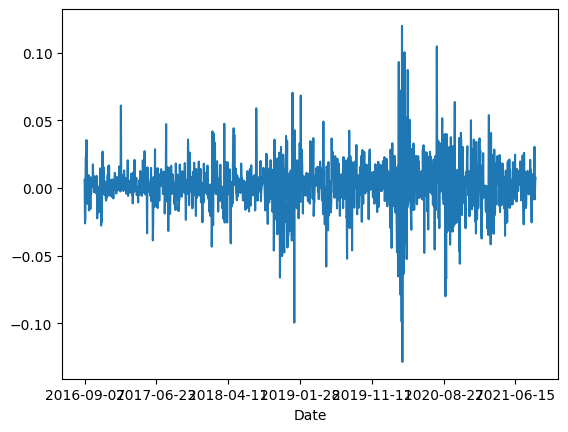

In [7]:
aapl['daily_return'].plot()

<AxesSubplot: >

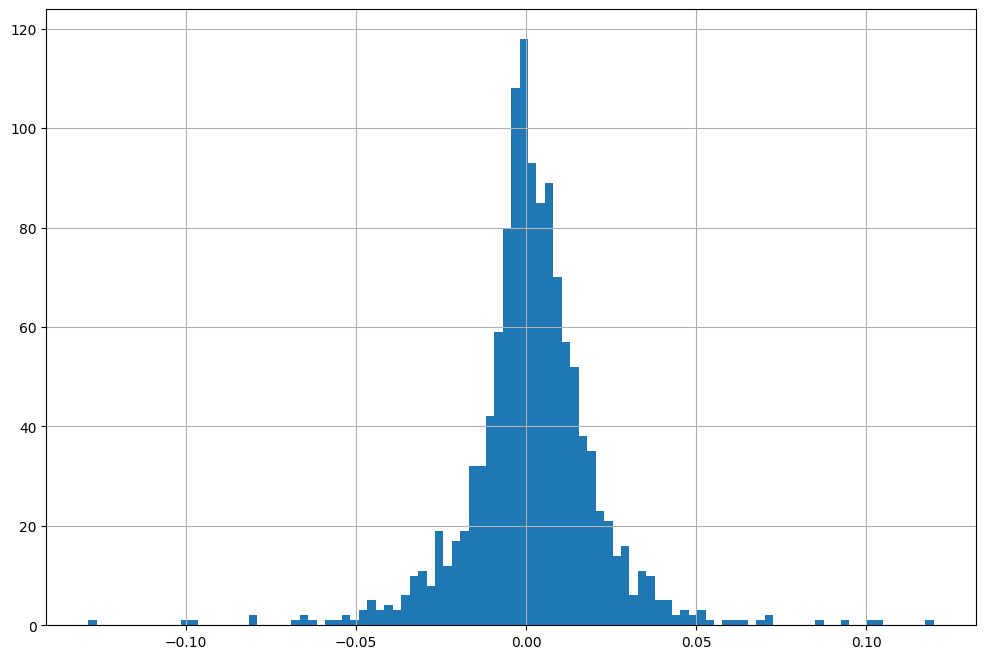

In [8]:
aapl['daily_return'].hist(bins=100, figsize=(12,8))

((array([-3.2629588 , -3.00266919, -2.857728  , ...,  2.857728  ,
          3.00266919,  3.2629588 ]),
  array([-0.12864692, -0.09960732, -0.09875466, ...,  0.10032545,
          0.10468866,  0.11980821])),
 (0.018232247416126675, 0.0016190904751974312, 0.9554464323217469))

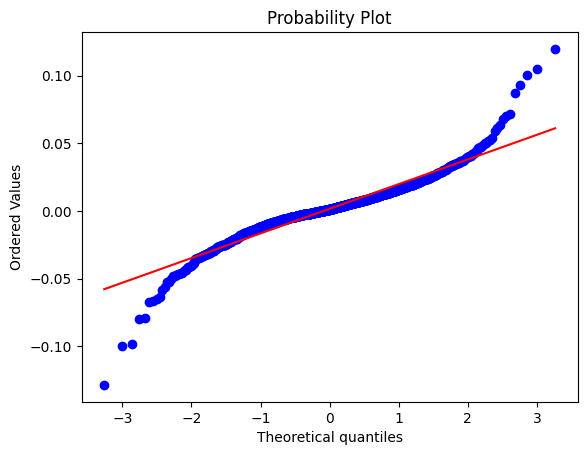

In [9]:
import scipy.stats as stats
import matplotlib.pyplot as plt
stats.probplot(aapl['daily_return'], dist='norm', plot=plt)

In [10]:
risk_free = pd.read_csv('/Users/savvastantalidis/python/Python-Finance-QuantConnect/06-Financial-Concepts-with-Python/1-year-treasury-rate-yield-chart.csv', parse_dates=True)
risk_free['date'] =  pd.to_datetime(risk_free['date'])
risk_free['date'] = risk_free['date'].dt.strftime('%Y-%m-%d')
risk_free.set_index('date',inplace=True)
risk_free.dropna(inplace=True)
risk_free['daily_change'] = risk_free['value'].pct_change(1).dropna()
risk_free = risk_free.dropna()

/var/folders/ns/2llvpxtd32z3xty61_xyx8t80000gn/T/ipykernel_16865/572962284.py:2: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  risk_free['date'] =  pd.to_datetime(risk_free['date'])


In [11]:
def compute_sharpe(df, risk_free = 0):
    """
    Compute Sharpe ratio for each asset in the dataframe.
    """
    if type(risk_free) == pd.DataFrame:
        try:
            index = df.index[0]
            risk_free = risk_free.loc[index:]
        except KeyError:
            try:
                index = df.index[1]
                risk_free = risk_free.loc[index:]
            except KeyError:
                index = df.index[2]
                risk_free = risk_free.loc[index:]
        
        mean_return = df['daily_return'].mean()
        std = df['daily_return'].std()
        risk_free_mean = risk_free['daily_change'].mean()

        sharpe_ration = (mean_return - risk_free_mean) / std

    else:
        mean_return = df['daily_return'].mean()
        std = df['daily_return'].std()
        sharpe_ration = (mean_return - risk_free) / std
    #annualized Sharpe ratio
    return sharpe_ration * np.sqrt(252)


In [12]:
def compute_sortino_ration(df, thresohold = 0, risk_free_rate = 0):

    mean_return = df['daily_return'].mean()

    std_sortino = df.loc[df['daily_return']< thresohold]['daily_return'].std()

    sortino = (mean_return - risk_free_rate) / std_sortino 

    return sortino * np.sqrt(252)


In [13]:
sortino_aapl = compute_sortino_ration(aapl, thresohold = 0, risk_free_rate = 0)
sortino_msft = compute_sortino_ration(msft, thresohold = 0, risk_free_rate = 0)

In [14]:
sortino_aapl, sortino_msft

(1.771416631240925, 1.695151173199415)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

# Create a sample DataFrame with daily return data

# Calculate mean and standard deviation of the returns
def compute_distribution(df):
    mean_return = df['daily_return'].mean()
    std_dev_return = df['daily_return'].std()

    # Create a histogram to visualize the distribution
    plt.hist(df['daily_return'], bins=30, density=True, alpha=0.6, color='blue', edgecolor='black')

    # Plot the theoretical bell curve
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean_return, std_dev_return)
    plt.plot(x, p, 'k', linewidth=2)

    plt.xlabel('Daily Return')
    plt.ylabel('Probability Density')
    plt.title('Distribution of Daily Returns')
    plt.show()

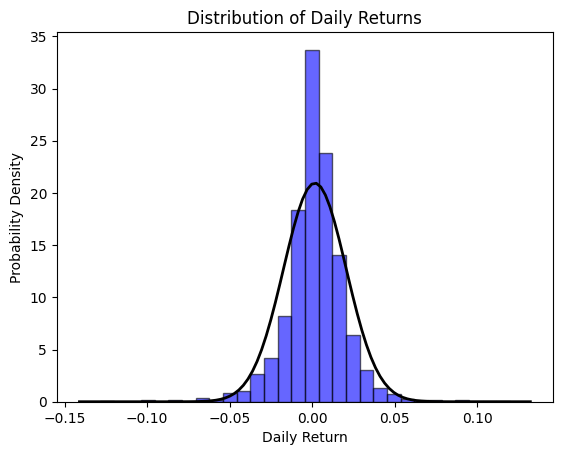

In [16]:
compute_distribution(aapl)

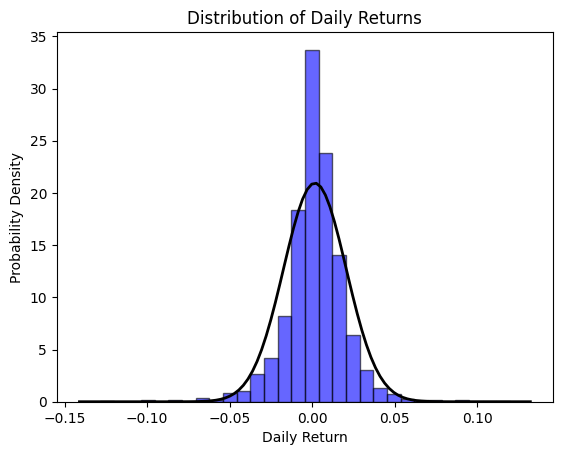

In [17]:
mean_return = aapl['daily_return'].mean()
std_dev_return = aapl['daily_return'].std()

# Create a histogram to visualize the distribution
plt.hist(aapl['daily_return'], bins=30, density=True, alpha=0.6, color='blue', edgecolor='black')

# Plot the theoretical bell curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean_return, std_dev_return)
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel('Daily Return')
plt.ylabel('Probability Density')
plt.title('Distribution of Daily Returns')
plt.show()

In [18]:
x

array([-0.14106968, -0.13830907, -0.13554845, -0.13278784, -0.13002723,
       -0.12726662, -0.124506  , -0.12174539, -0.11898478, -0.11622417,
       -0.11346355, -0.11070294, -0.10794233, -0.10518172, -0.1024211 ,
       -0.09966049, -0.09689988, -0.09413927, -0.09137865, -0.08861804,
       -0.08585743, -0.08309682, -0.0803362 , -0.07757559, -0.07481498,
       -0.07205437, -0.06929375, -0.06653314, -0.06377253, -0.06101192,
       -0.0582513 , -0.05549069, -0.05273008, -0.04996947, -0.04720885,
       -0.04444824, -0.04168763, -0.03892701, -0.0361664 , -0.03340579,
       -0.03064518, -0.02788456, -0.02512395, -0.02236334, -0.01960273,
       -0.01684211, -0.0140815 , -0.01132089, -0.00856028, -0.00579966,
       -0.00303905, -0.00027844,  0.00248217,  0.00524279,  0.0080034 ,
        0.01076401,  0.01352462,  0.01628524,  0.01904585,  0.02180646,
        0.02456707,  0.02732769,  0.0300883 ,  0.03284891,  0.03560952,
        0.03837014,  0.04113075,  0.04389136,  0.04665197,  0.04

In [28]:
def psr(df: DataFrame, benchmark_sr:float = 0):

    sr = compute_sharpe(df)
    skew = stats.skew(df['daily_return'])
    kurtosis = stats.kurtosis(df['daily_return'], fisher=True)
    n = len(df)

    sigma_sr = ((1/(n-1)) * (1+0.5*sr**2 - skew*sr + (kurtosis/4) * sr **2)       ) ** 0.5
    sigma_sr2 = ( (1 / (n-1)) * (1 + 0.5 * sr**2 - skew * sr + (kurtosis / 4) * sr**2))**0.5

    ratio = (sr - benchmark_sr) / sigma_sr

    psr = stats.norm.cdf(ratio)
    return psr

psr_aapl = psr(aapl)

In [20]:
psr_aapl = psr(aapl)


In [21]:
psr_aapl*(252**0.5)

11.840761925191211

In [22]:
psr_msft = psr(msft)
psr_msft*(252**0.5)

11.305138173323183

In [23]:
aapl

,Open,High,Low,Close,Adj Close,Volume,daily_return
Date,,,,,,,
2016-09-07,26.957500,27.190001,26.767500,27.090000,25.406099,169457200,0.006128
2016-09-08,26.812500,26.817499,26.309999,26.379999,24.740232,212008000,-0.026209
2016-09-09,26.160000,26.430000,25.782499,25.782499,24.179869,186228000,-0.022650
2016-09-12,25.662500,26.430000,25.632500,26.360001,24.721476,181171200,0.022399
2016-09-13,26.877501,27.197500,26.809999,26.987499,25.309967,248704800,0.023805
...,...,...,...,...,...,...,...
2021-08-27,147.479996,148.750000,146.830002,148.600006,148.600006,55721500,0.007185
2021-08-30,149.000000,153.490005,148.610001,153.119995,153.119995,90956700,0.030417
2021-08-31,152.660004,152.800003,151.289993,151.830002,151.830002,86453100,-0.008425
